<H1> Classification avec le jeu de données TITANIC </H1>

L'objectif est de poursuivre le TP précédente où de nombreux prétraitements ont été effecutés en ingénierie des données pour pouvoir faire un modèle de prédiction des survivants ou non.


<p align="center">
  <img src="http://www.lirmm.fr/~poncelet/Ressources/titanic.png"
       width="400">
</p>

Source : https://fr.wikipedia.org/wiki/Titanic

# Environnement

Ce notebook peut fonctionner sur plusieurs environnement `Jupyter`. Il n'est pas nécessaire d'utiliser un environnement disposant de GPU.  

**Pour les utilisateurs de Colab :**

Pour pouvoir utiliser votre répertoire `Google Drive`, il est nécessaire de fournir une autorisation. Pour cela il suffit de décommenter, si nécessaire, et d'exécuter la cellule suivante.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


Décommenter, si necessaire, les lignes et corriger la ligne `my_local_drive` pour mettre le chemin vers un répertoire spécifique de votre répertoire Google Drive.

In [2]:
import sys
import os

my_local_drive='/content/gdrive/MyDrive/Colab Notebooks/tp2_ml'

if not os.path.exists(my_local_drive):
    os.makedirs(my_local_drive)
    print(f"Dossier '{my_local_drive}' créé avec succès !")

sys.path.append(my_local_drive)

Il faut décommenter, si nécessaire, la ligne suivante pour se positionner dans le répertoire associé.

In [3]:
%cd {my_local_drive}

/content/gdrive/MyDrive/Colab Notebooks/tp2_ml


# Installation


Il faut utiliser la cellule suivante pour utiliser `optuna` qui n'est pas par défaut sous Colab. Il suffit, si nécessaire, de décommenter la ligne correspondante. Il faudra penser à importer la librairie.

In [4]:
# utiliser cette cellule pour installer les librairies manquantes
# pour cela il suffit de taper dans cette cellule :
# !pip install nom_librairie_manquante
# d'exécuter la cellule et de relancer la cellule suivante pour voir
# si tout se passe bien
#

!pip install optuna

# Eventuellement ne pas oublier de relancer le kernel du notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.9 MB/s eta 0:00:00



Les librairies utiles pour le TP sont toutes déclarées au début pour ne pas surcharger les affichages.

In [5]:
# Importation des différentes librairies utiles pour le notebook

#Sickit learn met régulièrement à jour des versions et
#indique des futurs warnings.
#ces deux lignes permettent de ne pas les afficher.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import joblib

import seaborn as sns
import matplotlib.pyplot as plt
import sys
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import sklearn
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

import optuna # Optimisation d'hyperparamètres

# Récupération du jeu de données

Si vous n'avez pas terminé le TP précédent ou si vous pensez avoir fait des erreurs, vous pouvez récupérer le fichier `titanic_clean.csv`. Attention si vous l'avez déjà il faut regarder dans votre répertoire de Google Drive que vous allez travailler, par la suite, avec le bon.

In [6]:
# %%capture
# !wget https://www.lirmm.fr/~poncelet/Ressources/titanic_clean.csv

# attention le séparateur est un ; ici
# df=pd.read_csv('titanic_clean.csv',sep=';')
# print (df.head())
# print (df.shape)
# print (df.columns)

In [51]:
path = '/content/gdrive/MyDrive/Colab Notebooks/tp1_ml/titanic_clean_2.csv'

try:
    df = pd.read_csv(path, sep=";")
    print("Fichier chargé avec succès !")
except FileNotFoundError:
    print(f"Erreur : Le fichier n'a pas été trouvé à l'emplacement : {path}")
    print("Vérifiez que le dossier 'tp1_ml' existe bien et que le nom du fichier est correct.")

Fichier chargé avec succès !


In [52]:
print(df.head())
print(df.shape)
print(df.columns)

   Survived  Sex       Age     SibSp     Parch      Fare  Embarked_Q  \
0         0    1 -0.437089  0.365311 -0.458217 -0.531122           0   
1         1    0  0.783472  0.365311 -0.458217  1.099279           0   
2         1    0 -0.131949 -0.584497 -0.458217 -0.513935           0   
3         1    0  0.554617  0.365311 -0.458217  0.636300           0   
4         0    1  0.554617 -0.584497 -0.458217 -0.510753           0   

   Embarked_S  Embarked_2  Embarked_3  HasCabin  Title_Miss  Title_Mr  \
0           1           0           1         0           0         1   
1           0           0           0         1           0         0   
2           1           0           1         0           1         0   
3           1           0           0         1           0         0   
4           1           0           1         0           0         1   

   Title_Mrs  Title_Rare  
0          0           0  
1          1           0  
2          0           0  
3          1        

Pour rappel, dans ce jeu de données, la colonne `Survived` utilise un codage binaire pour dire si une personne a survécu ou non :
- `0` signifie que le passager n'a pas survécu.
- `1` signifie que le passager a survécu.


# Visualisation du jeu de données

Avant d'entraîner des classifieurs, il est souvent utile d'obtenir une
représentation globale des données pour voir si des groupes naturels
apparaissent. L'ACP (Analyse en Composantes Principales) permet de projeter
les données dans un espace de plus faible dimension (souvent 2D/3D) tout en
conservant au mieux la variance.

Nous allons projeter les données sur deux composantes principales et
visualiser la distribution des passagers en distinguant les survivants et
les non-survivants. Cela permet parfois de voir si une séparation grossière
entre les classes semble possible.

In [54]:
# Colonnes numériques utilisées pour l'ACP
cols_for_pca = [
    'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q',
       'Embarked_S', 'Embarked_2', 'Embarked_3', 'HasCabin', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare'
]

X_pca = df[cols_for_pca].values

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# ACP sur 3 composantes
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": X_pca_3d[:, 0],
    "PC2": X_pca_3d[:, 1],
    "PC3": X_pca_3d[:, 2],
    "Survived": df["Survived"]
})

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=(
        "Projection 2D (PC1, PC2)",
        "Projection 3D (PC1, PC2, PC3)"
    )
)

# Scatter 2D à gauche
fig.add_trace(
    go.Scatter(
        x=df_pca["PC1"],
        y=df_pca["PC2"],
        mode="markers",
        marker=dict(
            color=df_pca["Survived"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(title="Survived")
        ),
        name="2D"
    ),
    row=1,
    col=1
)

fig.update_xaxes(title_text="PC1", row=1, col=1)
fig.update_yaxes(title_text="PC2", row=1, col=1)

# Scatter 3D à droite
fig.add_trace(
    go.Scatter3d(
        x=df_pca["PC1"],
        y=df_pca["PC2"],
        z=df_pca["PC3"],
        mode="markers",
        marker=dict(
            size=4,
            color=df_pca["Survived"],
            colorscale="Viridis",
            showscale=False
        ),
        name="3D"
    ),
    row=1,
    col=2
)

fig.update_scenes(
    xaxis_title="PC1",
    yaxis_title="PC2",
    zaxis_title="PC3",
    row=1,
    col=2
)

fig.update_layout(
    title="ACP du Titanic (2D et 3D)",
    width=900,
    height=450
)

fig.show()

> **Questions :**
>
> 1. Dans les projections 2D et 3D, observe-t-on une séparation claire entre survivants et non-survivants ?
> 2. Ces visualisations suggèrent-elles qu'un classifieur linéaire serait adapté ?
> 3. Quel type de classifieur semble le plus pertinent d'après l'ACP ?

In [ ]:
# Q1
# Pas vraiment

# Q2
# Non

# Q3
# Un classifieur non-linéaire (Random Forest ou SVM non-linéaire)

# Essai d'un classifier

Nous allons maintenant préparer les données pour entraîner un premier
classifieur. La variable à prédire est `Survived`. Les autres colonnes
servent de variables explicatives (features).

Dans ce dataframe, `Survived` est positionnée en première colonne.


> **À FAIRE :**  
> À partir du dataframe `df`, construire :
> - `X` : les colonnes descriptives,
> - `y` : la colonne cible `Survived`.

In [55]:
X = df.iloc[:, 1:]
y = df['Survived'].copy()

X.head()

,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Embarked_2,Embarked_3,HasCabin,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,-0.437089,0.365311,-0.458217,-0.531122,0,1,0,1,0,0,1,0,0
1,0,0.783472,0.365311,-0.458217,1.099279,0,0,0,0,1,0,0,1,0
2,0,-0.131949,-0.584497,-0.458217,-0.513935,0,1,0,1,0,1,0,0,0
3,0,0.554617,0.365311,-0.458217,0.636300,0,1,0,0,1,0,0,1,0
4,1,0.554617,-0.584497,-0.458217,-0.510753,0,1,0,1,0,0,1,0,0


> **Questions :**
>
> 1. Que représentent précisément les matrices `X` et `y` dans ce contexte ?
> 2. Combien d'observations et combien de variables explicatives contient `X` ?
> 3. Pourquoi est-il important de séparer explicitement `X` et `y` avant
>    d'entraîner un modèle ?


In [56]:
# Q1
# X représente l'entrée et Y la prédiction

# Q2
print(f"{X.shape}")
# 156 observations et 19 variables explicatives

# Q3
# X sert a entrainer et ajuster le modèle et y à faire une prédiction sur des données jamais vues

(156, 14)


Pour évaluer le classifieur, nous séparons le jeu de données en deux parties :
un jeu d'apprentissage (train) et un jeu de test (test). Le modèle sera
entraîné sur le jeu d'apprentissage et évalué sur le jeu de test.

Dans ce TP, nous prenons 30 % du jeu de données pour le test.

> **À FAIRE :**  
> Utiliser `train_test_split` pour découper `X` et `y` en quatre ensembles :
> `X_train`, `X_test`, `y_train`, `y_test`, en réservant 30 % des données
> pour le test.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

> **Questions :**
>
> 1. Pourquoi est-il important de garder un jeu de test séparé pour évaluer
>    le classifieur ?
> 2. Que se passerait-il si l'on évaluait le modèle sur les mêmes données
>    que celles utilisées pour l'apprentissage ?
> 3. Dans ce TP, combien d'exemples sont utilisés pour l'apprentissage,
>    et combien pour le test ?


In [58]:
# Q1
# Pour le tester sur des données qu'il n'a jamais vu

# Q2
# Il apprendrais les données d'entrainement par coeur

# Q3
# 108 pour l'apprentissage et 47 pour le test
print(len(X_train), len(y_test))

109 47


Nous allons utiliser un premier classifieur simple : `GaussianNB`
(naïve Bayes gaussien). L'objectif est d'obtenir une première valeur
d'accuracy, sans chercher encore à optimiser le modèle.

> **À FAIRE :**  
> Entraîner un classifieur `GaussianNB` sur `X_train`, `y_train`, puis
> prédire sur `X_test` et afficher l'accuracy obtenue.

In [67]:
from sklearn.naive_bayes import GaussianNB

GaussianNB = GaussianNB()
GaussianNB.fit(X_train, y_train)

GaussianNB()

In [68]:
y_pred = GaussianNB.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.46808510638297873


> **Questions :**
>
> 1. Que représente l'accuracy dans ce contexte ?
> 2. Cette mesure suffit-elle à juger de la qualité du modèle ? Pourquoi ?
> 3. À quoi pourrait-on comparer cette accuracy pour savoir si le modèle
>    fait mieux qu'un choix naïf ?


In [16]:
# Q1
# Le pourcentage de bonne réponse

# Q2
# Non, car elle est faites sans KFold, donc sur seulement 30% de nos données

# Q3
# Il est > à 50%

L’accuracy donne une vue globale, mais ne permet pas de savoir quelles erreurs
sont commises. La matrice de confusion et le classification report donnent des
informations plus détaillées sur les performances pour chaque classe.

> **À FAIRE :**  
> Afficher la matrice de confusion et le classification report associés aux
> prédictions du classifieur.

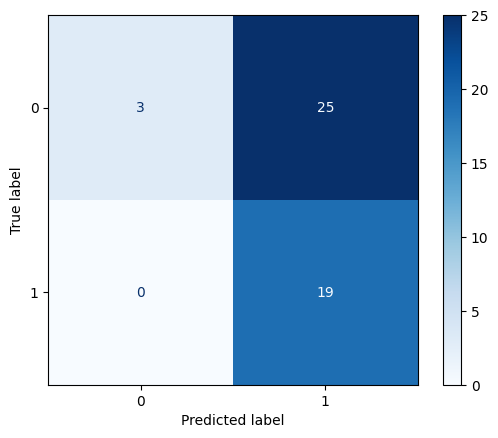

In [71]:
# confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.show()

In [72]:
print(classification_report(y_test, y_pred, target_names=["Survived", "Not survived"]))

              precision    recall  f1-score   support

    Survived       1.00      0.11      0.19        28
Not survived       0.43      1.00      0.60        19

    accuracy                           0.47        47
   macro avg       0.72      0.55      0.40        47
weighted avg       0.77      0.47      0.36        47



> **Questions :**
>
> 1. Que représentent les quatre cases de la matrice de confusion dans le
>    cas d'une classification binaire ?
> 2. Quels indicateurs sont fournis par le classification report ?
> 3. Le modèle semble-t-il mieux prédire les survivants ou les non-survivants ?
>    Justifier à partir des résultats.


In [73]:
# Q1
# Les vrais positifs, faux positifs, faux negatif et vrai negatif

# Q2
# Precision, rappel, F1 et support

# Q3
# Les non survivant avec 90% d'accuracy

L'évaluation sur un seul découpage apprentissage/test peut dépendre de la
façon dont les données ont été séparées. La validation croisée consiste à
répéter l'évaluation sur plusieurs découpages et à observer la variabilité
des résultats.

> **À FAIRE :**  
> Mettre en place une validation croisée avec `KFold` (10 splits) et appliquer
> le classifieur `GaussianNB` sur chaque split pour obtenir une liste de
> valeurs d'accuracy.


In [74]:
kf = KFold(n_splits = 10, shuffle =True)

# from sklearn.model_selection import StratifiedKFold
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [75]:
def train_model_kfold(model, kfold, X, y):
  accuracy = []
  std = 0

  for train_index, test_index in kfold.split(X):
      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y.iloc[train_index], y.iloc[test_index]

      model.fit(X_train, y_train)
      y_pred = model.predict(X_test)

      acc = accuracy_score(y_test, y_pred)
      accuracy.append(acc)

  std = np.std(accuracy)
  accuracy_global = np.mean(accuracy)

  return accuracy, accuracy_global, std

In [76]:
def print_result(model, accuracy, std):
  print(f"{model} :\n\tAccuracy : {accuracy}\n\tEcart type : {std}")

In [79]:
gaussian_acc, gaussien_acc_global, gaussian_std = train_model_kfold(GaussianNB, kf, X_train, y_train)

print_result("GaussianNB", gaussien_acc_global, gaussian_std)

# 60% accuracy et 17% ecart type

GaussianNB :
	Accuracy : 0.36909090909090914
	Ecart type : 0.13087120663947713


> **Questions :**
>
> 1. Quel est l'intérêt d'utiliser une validation croisée par rapport à un
>    seul découpage apprentissage/test ?
> 2. Que signifie l'écart-type des accuracy sur les 10 folds ?
> 3. Un modèle avec une accuracy moyenne correcte mais un écart-type très
>    élevé serait-il rassurant ? Pourquoi ?


In [ ]:
# Q1
# On peut tester le modèle sur l'intégralité des données

# Q2
# L'écart moyen d'accuracy entre tous les fold

# Q3
# Non cela veut dire que le mdoèle a du mal a généraliser

# Utilisation de plusieurs classifiers

Nous allons maintenant comparer plusieurs classifieurs sur le même jeu de
données. L'idée est d'obtenir une première vision de leurs performances
moyennes et de leur stabilité à l'aide d'une validation croisée.

Les classifieurs testés seront :
`KNeighborsClassifier`, `DecisionTreeClassifier`, `GaussianNB`, `SVC` et
`RandomForestClassifier`.

> **À FAIRE :**  
> Définir une liste de modèles, puis utiliser la validation croisée
> (KFold, 10 splits) pour calculer l'accuracy moyenne et l'écart-type
> de chaque classifieur.

In [80]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

model_knn = KNeighborsClassifier(n_neighbors=3)
model_tree = DecisionTreeClassifier(random_state=0)
model_svc = make_pipeline(StandardScaler(), SVC(gamma='auto'))
model_rf = RandomForestClassifier(max_depth=2, random_state=0)

model_list = [model_knn, model_tree, model_svc, model_rf]

In [91]:
def train_models(model_list, kfold, X, y):
  results = []

  for model in model_list:
    acc, acc_global, std = train_model_kfold(model, kfold, X, y)

    results.append(acc)

    print(f"{model} :\n\tAccuracy : {acc_global}\n\tEcart type : {std}\n")

  return results

In [94]:
results = train_models(model_list, kf, X_train, y_train)

KNeighborsClassifier(n_neighbors=3) :
	Accuracy : 0.78
	Ecart type : 0.12944892735510954

DecisionTreeClassifier(random_state=0) :
	Accuracy : 0.8
	Ecart type : 0.133608531424537

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto'))]) :
	Accuracy : 0.7981818181818181
	Ecart type : 0.10584566965693007

RandomForestClassifier(max_depth=2, random_state=0) :
	Accuracy : 0.8345454545454546
	Ecart type : 0.08960888385710258



In [ ]:
# Q1
# Random forest a l'aire meilleur avec decision tree

# Q2
# Random forest

# Q3
# En accruacy ils sont proches mais loin en ecart type

> **Questions :**
>
> 1. Quel classifieur obtient la meilleure accuracy moyenne ?
> 2. Quel classifieur semble le plus stable (plus faible écart-type) ?
> 3. La différence entre les classifieurs est-elle très marquée ou
>    relativement faible ?


Pour mieux comparer les distributions des accuracy des différents
classifieurs, nous pouvons représenter les résultats avec un boxplot.

> **À FAIRE :**  
> Afficher un boxplot des résultats de validation croisée pour chaque
> classifieur.


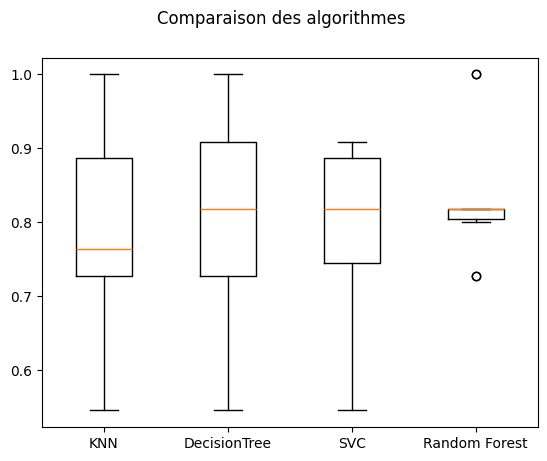

In [95]:
names = ["KNN", "DecisionTree", "SVC", "Random Forest"]

fig = plt.figure()
fig.suptitle("Comparaison des algorithmes")
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [101]:
def print_box_plot(names, results):
  fig = plt.figure()
  ax = fig.add_subplot(111)
  plt.boxplot(results)
  ax.set_xticklabels(names)
  plt.show()

> **Questions :**
>
> 1. Le boxplot confirme-t-il le classifieur le plus performant en moyenne ?
> 2. Certains classifieurs présentent-ils des résultats très dispersés ?
> 3. Ce graphique vous aide-t-il à choisir un classifieur de base pour la
>    suite du TP ? Justifier.


Les premiers résultats de validation croisée montrent que
`RandomForestClassifier` fait partie des meilleurs classifieurs. Nous allons
maintenant chercher une combinaison d'hyperparamètres plus adaptée à ce
jeu de données à l'aide de `GridSearchCV`.

> **À FAIRE :**  
> Utiliser `GridSearchCV` pour tester plusieurs jeux de paramètres pour
> `RandomForestClassifier` (nombre d'arbres, profondeur, critères,
> etc.), en vous appuyant sur la grille définie dans la cellule de code
> suivante. Afficher le meilleur score obtenu et les paramètres associés.

In [113]:
grid_param_rf = {
    "n_estimators": [4, 6, 9],
    "max_features": ["log2", "sqrt"],
    "criterion": ["entropy", "gini"],
    "max_depth": [2, 3, 5, 10],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 5, 8]
}

In [114]:
grid = GridSearchCV(RandomForestClassifier(), grid_param_rf)

grid.fit(X_train, y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [2, 3, 5, 10],
                         'max_features': ['log2', 'sqrt'],
                         'min_samples_leaf': [1, 5, 8],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [4, 6, 9]})

In [115]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 4}


In [116]:
model_rf_opti = RandomForestClassifier(max_depth=3, criterion="gini", max_features="log2", min_samples_split=3, n_estimators=4, min_samples_leaf=1)

RandomForestClassifier(max_depth=2, random_state=0) :
	Accuracy : 0.8163636363636364
	Ecart type : 0.07062881672565464

RandomForestClassifier(max_depth=3, max_features='log2', min_samples_split=3,
                       n_estimators=4) :
	Accuracy : 0.8
	Ecart type : 0.11354541815269814



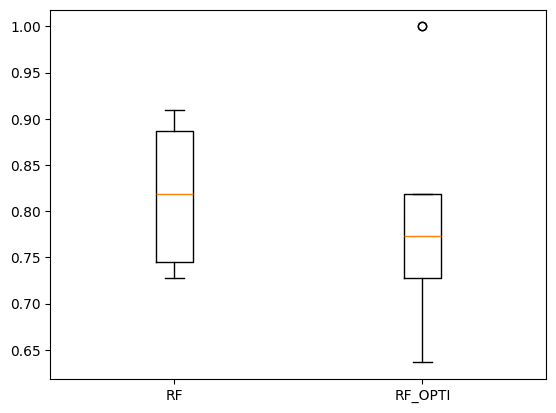

In [119]:
model_list = [model_rf, model_rf_opti]
results = train_models(model_list, kf, X_train, y_train)
print_box_plot(["RF", "RF_OPTI"], results)

In [ ]:
# Q1
# En fonction des tirages, oui et non

# Q2
# Un modèle simple, avec 3 de max depth et 5 en estimators

# Q3
# Car grid search fait des ajustements de paramètres, que l'on ne fait que pendant l'entrainement, afin de ne pas fausser les tests

> **Questions :**
>
> 1. Le meilleur score trouvé par GridSearchCV est-il supérieur à l'accuracy
>    moyenne obtenue précédemment avec RandomForestClassifier par défaut
>    (environ 0.79) ?
> 2. Quels hyperparamètres ont été retenus (profondeur, nombre d'arbres,
>    etc.) ? Ces valeurs correspondent-elles plutôt à un modèle simple
>    ou complexe ?
> 3. Pourquoi utilise-t-on uniquement `X_train`, `y_train` dans GridSearchCV
>    et non l'ensemble des données (train + test) ?



`DecisionTreeClassifier` faisait partie des modèles les plus stables lors de la
validation croisée. Nous allons maintenant rechercher automatiquement les
hyperparamètres les plus adaptés en utilisant `GridSearchCV`.



> **À FAIRE :**  
> Utiliser GridSearchCV avec la grille de paramètres proposée ci-dessous
> afin d'identifier la meilleure configuration pour DecisionTreeClassifier.
> Afficher le meilleur score et les paramètres associés.


In [120]:
grid_param_dt = {
    "max_depth": [1,2,3,4,5,6,7,8,9,10],
    "criterion": ["gini", "entropy"],
    "min_samples_leaf": [1,2,3,4,5,6,7,8,9,10]
}

In [123]:
grid = GridSearchCV(DecisionTreeClassifier(), grid_param_dt)

grid.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [124]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 1, 'min_samples_leaf': 1}


In [126]:
model_tree_opti = RandomForestClassifier(max_depth=1, criterion="gini", min_samples_leaf=1)

DecisionTreeClassifier(random_state=0) :
	Accuracy : 0.7618181818181818
	Ecart type : 0.10039591048929836

RandomForestClassifier(max_depth=1) :
	Accuracy : 0.7427272727272728
	Ecart type : 0.10679787040932487



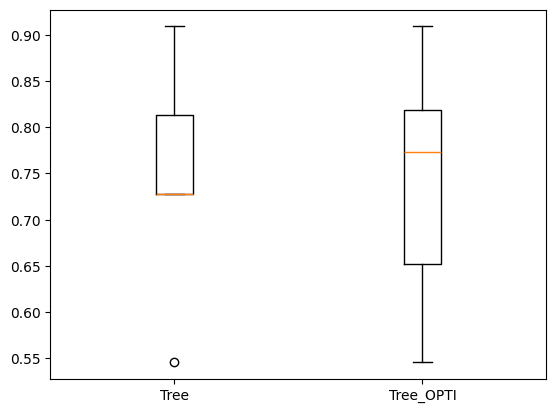

In [130]:
model_list = [model_tree, model_tree_opti]
results = train_models(model_list, kf, X_train, y_train)
print_box_plot(["Tree", "Tree_OPTI"], results)

In [ ]:
# Q1
# Il est très variant

# Q2
# Plutot simple

# Q3
# Il peut faire des généralités sur des spécificités

> **Questions :**
>
> 1. Le score obtenu après GridSearch est-il supérieur ou proche de celui
>    obtenu avec l'arbre par défaut ?
> 2. Les paramètres optimums indiquent-ils un arbre plutôt simple ou complexe ?
> 3. Pourquoi augmenter trop la profondeur peut-il dégrader les performances ?


Le classifieur `SVC` donne de bons résultats mais dépend fortement de ses
hyperparamètres (`C`, `gamma`, `kernel`). Nous allons utiliser`GridSearchCV`
pour explorer une grille raisonnable.

> **À FAIRE :**  
> Tester les paramètres proposés ci-dessous avec GridSearchCV et afficher le
> meilleur score ainsi que les hyperparamètres qui l'ont produit.


In [132]:
grid_param_svc = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["linear", "rbf"]
}

In [133]:
grid = GridSearchCV(SVC(), grid_param_svc)

grid.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10],
                         'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['linear', 'rbf']})

In [134]:
print(grid.best_params_)

{'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}


In [135]:
model_svc_opti = SVC(C=0.1, gamma=0.001, kernel="linear")

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto'))]) :
	Accuracy : 0.7627272727272728
	Ecart type : 0.12885060860874106

SVC(C=0.1, gamma=0.001, kernel='linear') :
	Accuracy : 0.8263636363636364
	Ecart type : 0.11758239593880855



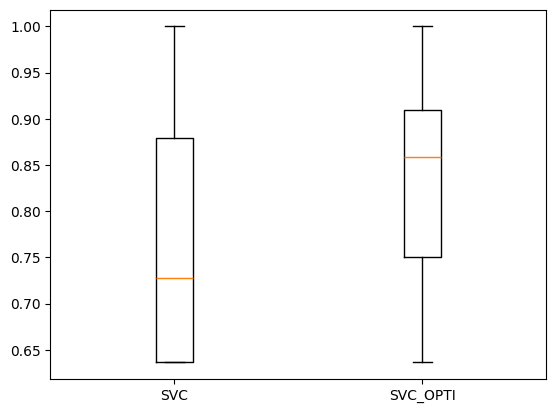

In [142]:
model_list = [model_svc, model_svc_opti]
results = train_models(model_list, kf, X_train, y_train)
print_box_plot(["SVC", "SVC_OPTI"], results)

In [ ]:
# Q1
# Car c'est la manière dont le modèle trace sa séparation (droite, cercle, etc)

# Q2
# Contrôle la sévérité de la pénalité accordée aux erreurs de classification

# Q3
# Définie la tolérance entre les points localement

> **Questions :**
>
> 1. Pourquoi le choix du kernel influe-t-il autant sur les performances ?
> 2. Comment interpréter un grand C ou un faible C ?
> 3. Que représente le paramètre gamma dans un kernel RBF ?


`GridSearchCV` explore systématiquement une grille de paramètres, mais peut
devenir coûteux lorsque le nombre de combinaisons augmente. Nous allons
maintenant utiliser `Optuna`, une bibliothèque d'optimisation bayésienne,
pour rechercher automatiquement de bons hyperparamètres pour
`RandomForestClassifier`.

> **À FAIRE :**  
> 1. Définir une fonction objectif pour Optuna qui, pour un essai
>    (`trial`), instancie un RandomForestClassifier avec des
>    hyperparamètres proposés par Optuna.  
> 2. Évaluer le modèle par validation croisée sur `X_train`, `y_train`
>    et retourner l'accuracy moyenne.  
> 3. Lancer l'optimisation sur un nombre raisonnable d'essais (par
>    exemple 50) et afficher le meilleur score et les meilleurs
>    hyperparamètres trouvés.


In [144]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 1, 500),
        'max_depth': trial.suggest_int('max_depth', 1, 10),
        'random_state': 0
    }

    model = RandomForestClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=5).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print(study.best_params)
print(study.best_value)

[I 2026-03-02 22:09:45,295] A new study created in memory with name: no-name-8387ade8-f91b-4e7b-8a4b-882c60fcfb72
[I 2026-03-02 22:09:46,093] Trial 0 finished with value: 0.8437229437229437 and parameters: {'n_estimators': 82, 'max_depth': 8}. Best is trial 0 with value: 0.8437229437229437.
[I 2026-03-02 22:09:46,768] Trial 1 finished with value: 0.8532467532467531 and parameters: {'n_estimators': 71, 'max_depth': 9}. Best is trial 1 with value: 0.8532467532467531.
[I 2026-03-02 22:09:47,939] Trial 2 finished with value: 0.8341991341991342 and parameters: {'n_estimators': 125, 'max_depth': 3}. Best is trial 1 with value: 0.8532467532467531.
[I 2026-03-02 22:09:49,227] Trial 3 finished with value: 0.8437229437229437 and parameters: {'n_estimators': 138, 'max_depth': 9}. Best is trial 1 with value: 0.8532467532467531.
[I 2026-03-02 22:09:49,535] Trial 4 finished with value: 0.8437229437229437 and parameters: {'n_estimators': 46, 'max_depth': 7}. Best is trial 1 with value: 0.853246753246

{'n_estimators': 71, 'max_depth': 9}
0.8532467532467531


In [ ]:
# Q1
# Légèrement supérieur : 0.85

# Q2
# Ils sont différents, optuna a l'occasion de chercher beaucoup plus de paramètres

# Q3
# Optnua semble moins linéaire et plus logique, il est cependant plus long

> **Questions :**
>
> 1. Le meilleur score obtenu avec Optuna est-il supérieur, inférieur
>    ou proche de celui obtenu avec GridSearchCV sur RandomForestClassifier
>    (environ 0.833 dans notre exemple) ?
> 2. Les hyperparamètres trouvés par Optuna sont-ils similaires à ceux
>    trouvés par GridSearchCV (profondeur, nombre d'arbres, etc.) ou
>    différents ? Comment l'expliquer ?
> 3. Quels avantages et inconvénients voyez-vous à l'utilisation
>    d'Optuna par rapport à GridSearchCV dans ce contexte ?


# Préparation à la mise en production

L'objectif de cette section est de préparer un modèle final qui pourrait
être utilisé en production. Nous allons :
1. mettre de côté quelques passagers pour un test final,
2. choisir le meilleur classifieur avec ses hyperparamètres,
3. construire un pipeline pour ce modèle,
4. sauvegarder le modèle,
5. le tester sur les passagers mis de côté.


Avant d'entraîner le modèle final, nous allons sélectionner quelques
observations qui ne seront pas utilisées pour l'apprentissage. Elles
serviront uniquement à évaluer le modèle sauvegardé.

> **À FAIRE :**  
> 1. Tirer aléatoirement 4 lignes du DataFrame `df`.  
> 2. Les stocker dans un nouveau DataFrame, `df2`, pour un test final.  
> 3. Supprimer ces lignes de `df` afin qu'elles ne participent pas à
>    l'entraînement.

In [145]:
df2 = df.sample(n=4, random_state=42)
df = df.drop(df2.index)

Le DataFrame `df` contient maintenant toutes les données qui serviront à
l'apprentissage du modèle final (les 4 passagers mis de côté sont dans
`df2` et ne sont plus dans `df`).

> **Attention :** il est important de réutiliser **l'ensemble de ces données** pour entraîner le modèle définitif, car tous les choix de modèles et
d'hyperparamètres ont déjà été faits à partir des expérimentations
précédentes (validation croisée, GridSearch, Optuna, etc.).

> **À FAIRE :**  
> 1. Définir `X` comme l'ensemble des colonnes explicatives.  
> 2. Définir `y` comme la colonne cible `Survived`.

In [146]:
X = df.iloc[:, 1:]
y = df['Survived'].copy()

Nous allons maintenant créer un pipeline qui contient le classifieur
retenu à l'issue des expérimentations. Par exemple, les tests ont pu
montrer qu'un `RandomForestClassifier` avec les paramètres suivants
donne de bons résultats :

`RandomForestClassifier(max_depth=2, min_samples_leaf=5,
min_samples_split=5, n_estimators=6)`

> **Attention :** dans ce TP, les opérations de préparation des données (normalisation,
> imputation, encodage) ont été faites en amont. En production, ces
> étapes devraient **OBLIGATOIREMENT être intégrées dans le pipeline** (par exemple avec
> `StandardScaler`, des imputers, etc.). Lors de l'étape d'ingénierie des données nous avons normalisé les données.
>
> Là il y a clairement un biais : on ne peut pas normaliser les données du jeu de test dans les expérimentations. Elles doivent juste appliquer un `transform` pour appliquer la normalisation qui est faite sur le jeu d'apprentissage sinon cela veut dire que le modèle sait à l'avance le futur !!!.  
>
>Nous avons fait ce choix par soucis de simplification mais il ne faut pas oublier que le `StandardScaler` lors des expérimentations ne se fait que sur la partie apprentissage. Dans le pipeline il faudrait donc, comme on travaille sur l'ensemble des données l'intégrer avant le classifier comme ça pour toute nouvelle donnée on appliquera la normalisation.

> **À FAIRE :**  
> 1. Créer un `RandomForestClassifier` avec les hyperparamètres retenus.  
> 2. Construire un pipeline qui contient ce classifieur.  
> 3. Entraîner ce pipeline sur `X` et `y`.

In [148]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Classifieur final (à adapter si besoin selon vos propres résultats)
final_clf = RandomForestClassifier(
    max_depth=9,
    n_estimators=71
)

# Pipeline minimal contenant le classifieur
pipeline_final = Pipeline([
    ("clf", final_clf)
])

# Entraînement du pipeline sur toutes les données disponibles
pipeline_final.fit(X, y)

Pipeline(steps=[('clf', RandomForestClassifier(max_depth=9, n_estimators=71))])

Une fois le pipeline entraîné sur l'ensemble du jeu de données, il est
important de le sauvegarder afin de pouvoir le réutiliser plus tard,
sans avoir à réentraîner le modèle.

Nous allons utiliser le format `.joblib`, adapté pour les objets
scikit-learn.

> **À FAIRE :**  Sauvegarder le pipeline entraîné dans un fichier `.joblib`.  



In [149]:
# Nom du fichier à créer
model_filename = "titanic_model.joblib"

# Sauvegarde du pipeline
joblib.dump(pipeline_final, model_filename)

['titanic_model.joblib']

Nous allons maintenant recharger le modèle sauvegardé et l'utiliser pour
prédire la survie des 4 passagers stockés dans `df2`.

> **À FAIRE :**  
> 1. Recharger le modèle sauvegardé à partir du fichier `.joblib`.  
> 2. Séparer `df2` en `X_test` (variables explicatives) et `y_test`
>    (colonne `Survived`).  
> 3. Prédire la survie des passagers de `df2`.  
> 4. Afficher, pour chaque passager, la vraie valeur et la valeur prédite.


In [152]:
# Rechargement du modèle
model_filename = "titanic_model.joblib"
loaded_model = joblib.load(model_filename)

# Séparation X / y pour le test final
X_test = df2.drop(columns=["Survived"])
y_test = df2["Survived"]

# Prédictions
y_pred = loaded_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Survived", "Not survived"]))

              precision    recall  f1-score   support

    Survived       1.00      1.00      1.00         3
Not survived       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



Ce TP avait pour objectif de parcourir l'ensemble des étapes de travail
classique d'un projet de classification supervisée, depuis l'exploration
initiale des données jusqu'à la mise en production d'un modèle final.

Nous avons d'abord travaillé sur l'ingénierie des données : inspection
des colonnes, gestion des valeurs manquantes, encodage et normalisation.
Ces étapes sont essentielles, car un modèle d'apprentissage automatique
n'est performant que si les données en entrée sont correctement
préparées.

La phase de visualisation du TP précédent a permis d'observer les grandes tendances du
jeu de données : influence de la classe sociale, du sexe, du port
d'embarquement, etc. Dans ce TP l'utilisation d'une ACP a montré que les classes ne sont pas linéairement
séparables, ce qui explique pourquoi nous n'avons pas utilisé de
modèles linéaires simples comme `LinearRegression`. D'autres méthodes, comme les arbres de
décision ou les forêts aléatoires, se prêtent mieux à ce type de
structure.

Nous avons ensuite évalué plusieurs classifieurs, comparé leurs
performances et recherché de bons hyperparamètres. Cela rappelle qu'un
modèle n'est jamais "bon" simplement en utilisant ses valeurs par
défaut, même si ces valeurs permettent souvent d'obtenir une première
tendance utile pour éliminer certains classifieurs. Nous avons également
vu que l'efficacité d'un modèle dépend fortement du réglage de ses
hyperparamètres et, plus largement, d'expérimentations systématiques.
Cependant, ces recherches sont coûteuses en temps de calcul et en
ressources : il est donc essentiel de toujours réfléchir à leur utilité
avant de les lancer.

L"étape finale a consisté à préparer une mise en production simplifiée :
séparation de données pour un test final, création d"un pipeline et
sauvegarde du modèle. Il faut garder en tête que, dans un contexte
réel, les étapes de pré-traitement (imputation, encodage, normalisation)
doivent être intégrées directement dans le pipeline afin d'éviter les
biais liés aux transformations effectuées en dehors de l'apprentissage.

L'objectif de ces 2 TP était de vous montrer une vision globale du cycle
d'apprentissage d'un modèle : comprendre les données, les transformer,
les visualiser, choisir un classifieur, l'évaluer, l'améliorer, et
enfin préparer son déploiement. Il s'agit de la mise en place de la chaîne de traitement : ces étapes se retrouvent dans la
majorité des projets de machine learning.